# Beta-binomial distribution example

This notebook demonstrates the use of the beta-binomial distribution to analyze the probability of observing a certain number of successes ("good measurements") in a series of trials. It uses the `scipy.stats.betabinom` and `scipy.stats.beta` distributions to:

- Visualize the probability mass function (PMF) and cumulative distribution function (CDF) for the beta-binomial distribution.
- Calculate and plot confidence intervals for the expected number of successes.
- Show how to determine the upper threshold for the expected number of new trials needed to achieve a given confidence level, given the number of successes so far.

## Why use the Beta distribution?

Suppose you perform a number of trials (shots), some of which fail. You want to estimate the probability of success and predict the number of new trials needed to achieve a certain confidence level for future successes.

The beta-binomial distribution is well-suited for this scenario because:

- **Uncertainty in Success Probability**: The true probability of success ($p$) is unknown. The Beta distribution serves as a prior for $p$, representing our initial beliefs before seeing any data.
- **Bayesian Updating**: After observing data (number of successes and failures), we update our beliefs about $p$ using the Beta posterior.
- **Marginalizing Over $p$**: The beta-binomial distribution arises when we account for both the randomness of the trials and our uncertainty about $p$ by integrating (marginalizing) over the Beta prior.
- **Interpretation**: This approach allows us to model the number of successes in a fixed number of trials, incorporating both observed data and prior uncertainty.

**Note:**
If we have no prior knowledge about $p$, we use a uniform Beta prior with parameters $a=1$ and $b=1$. This represents complete uncertainty about the probability of success before observing any data.

In [1]:
import numpy as np
from scipy.stats import betabinom, beta
import matplotlib.pyplot as plt

In [2]:
n, a = 1000, 975
conf_lim_1tail = 0.99
conf_lim_2tail = 1 - (1 - conf_lim_1tail) * 2
b = n - a
# Update parameters to include the uniform prior: a+1, b+1
n, a, b, conf_lim_1tail, conf_lim_2tail

(1000, 975, 25, 0.99, 0.98)

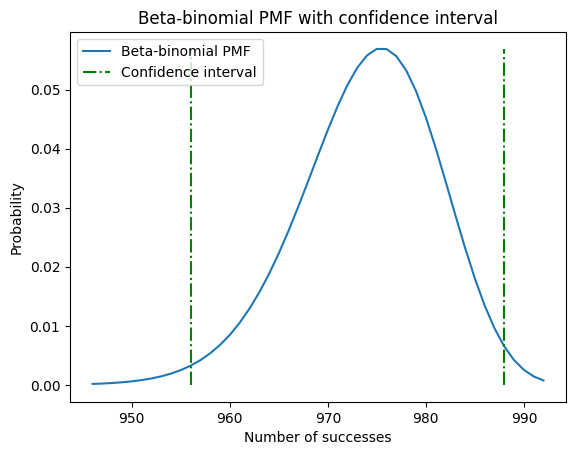

In [3]:
# Show the pdf of the expected number of good measurements for a new trial, given the number of good measurements so far (a) and the number of bad measurements (b).
# Also the 2-tail confidence interval (centered around the median)
fig, ax = plt.subplots(1, 1)
plot_width = betabinom.interval(0.999, n, a + 1, b + 1)
x = np.arange(*plot_width)
pmf = betabinom.pmf(x, n, a + 1, b + 1)
ax.plot(x, pmf, label="Beta-binomial PMF")
conf_int = betabinom.interval(conf_lim_2tail, n, a + 1, b + 1)
ax.vlines(conf_int, 0, max(pmf), colors="g", linestyles="-.", label="Confidence interval")
ax.set_xlabel("Number of successes")
ax.set_ylabel("Probability")
ax.set_title("Beta-binomial PMF with confidence interval")
ax.legend()

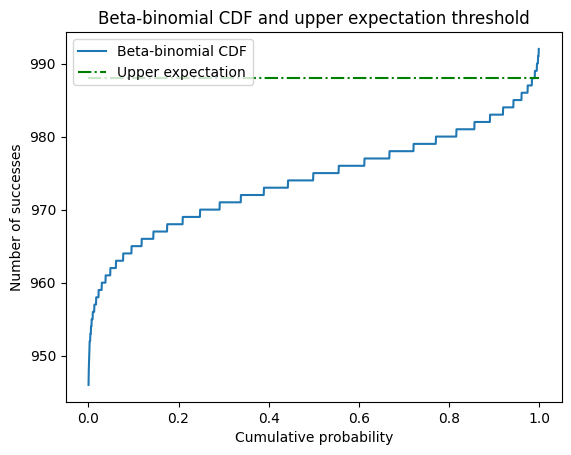

In [4]:
# Alternatively, plot the cdf of a new trial showing the 1-tailed threshold
step = 0.0005
x = np.arange(0, 1, step)
x = x[1:-1]
plt.figure()
plt.plot(x, betabinom.ppf(x, n, a + 1, b + 1), label="Beta-binomial CDF")
upper_expectation = betabinom.ppf(conf_lim_1tail, n, a + 1, b + 1)
plt.hlines(upper_expectation, 0, 1, colors="g", linestyles="-.", label="Upper expectation")
plt.xlabel("Cumulative probability")
plt.ylabel("Number of successes")
plt.title("Beta-binomial CDF and upper expectation threshold")
plt.legend()

In [5]:
upper_expectation, conf_int

(np.float64(988.0), (np.float64(956.0), np.float64(988.0)))

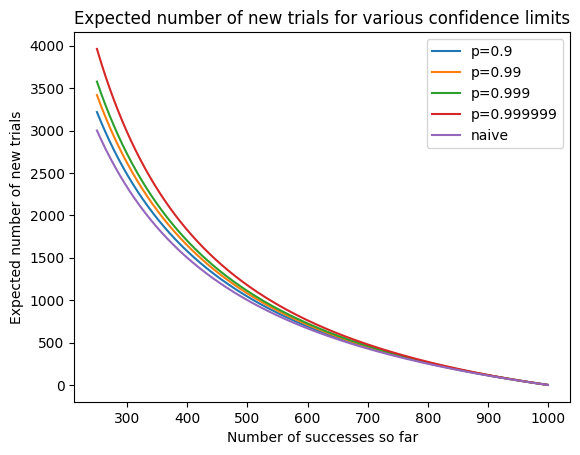

In [6]:
# Calculate the upper threshold of expected number of new trials
# needed for each confidence limit given the number of good measurements so far
# Use Beta posterior with prior a=1, b=1, so parameters are n_passes+1, n_failures+1
def calc_upper_conf(n_trials, n_passes, conf_lim_1tail):
    n_failures = n_trials - n_passes
    lower_passrate = beta.ppf(1 - conf_lim_1tail, n_passes + 1, n_failures + 1)
    exp_trials = n_failures / lower_passrate
    return exp_trials


x = np.arange(250, n)
plt.figure()
for conf_lim in [0.9, 0.99, 0.999, 0.999999]:
    plt.plot(x, calc_upper_conf(n, x, conf_lim), label=f"p={conf_lim}")
# naive expectation of number of new trials needed to get n passes, given x passes so far:
# this is just the expected number of failures divided by the pass rate, without accounting for uncertainty in the pass rate.
naive = (n - x) / (x / n)
plt.plot(x, naive, label="naive")
plt.xlabel("Number of successes so far")
plt.ylabel("Expected number of new trials")
plt.title("Expected number of new trials for various confidence limits")
plt.legend()